In [155]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [156]:
loaded_data = datasets.fetch_openml('mnist_784', version=1, as_frame=False)

In [157]:
softmax = lambda Z: (E := np.exp(Z)) / np.sum(E, axis=1, keepdims=True)

In [158]:
sigma = lambda X, W: X @ W

In [159]:
grad = lambda X, S, T: X.T @ (S - T) / S.shape[0]

In [160]:
x_entropy = lambda T, S: -np.sum(T * np.log(S + 1e-8)) / S.shape[0]

In [161]:
forward = lambda X, W: softmax(sigma(X,W))

In [162]:
backward = lambda  X, W, S, T, lr: W - lr * grad(X, S, T)

In [163]:
X, y = loaded_data.data, loaded_data.target
X = X.astype(np.float32)
X /= 255.0

In [164]:
np.sqrt(X[0].shape[0])

np.float64(28.0)

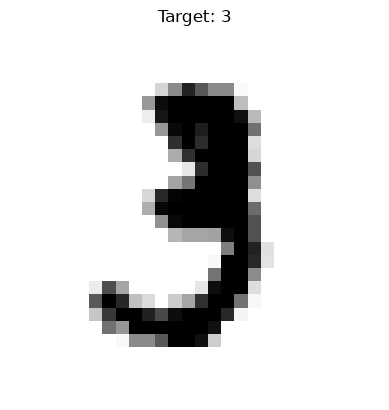

In [165]:
plt.imshow(np.reshape(X[10], (28, 28)), cmap='binary')
plt.axis('off')
plt.title(f"Target: {y[10]}")
plt.show()

In [166]:
np.random.seed(42)
num_epoch = 1000
W = np.random.rand(784, 10) * 0.01
T = np.eye(10)[y.astype(int)] # TODO one hot
num_data = X.shape[0]
split = int(num_data * .8)
shuffle = np.random.permutation(num_data)
X_train, T_train = X[shuffle[:split]], T[shuffle[:split]]
X_test, T_test = X[shuffle[split:]], T[shuffle[split:]]
lr = 0.1
snapshot_delay = 100
test_labels = np.argmax(T_test, axis=1)
num_test = X_test.shape[0]

In [167]:
for epoch in range(num_epoch):
    # forward
    S_train = softmax(sigma(X_train, W))
    if epoch % snapshot_delay == 0:
        preds = np.argmax(softmax(sigma(X_test, W)), axis=1)    
        acc = np.sum(test_labels == preds)/num_test
        train_loss = x_entropy(T_train, S_train[:split])
        S_test = softmax(sigma(X_test, W))
        test_loss = x_entropy(T_test, S_test)
        print(f"Epoch: {epoch} acc: {acc}")
        print("Train loss: ", train_loss)
        print("Test loss: ", test_loss)
    # backward
    W -= lr * grad(X_train, S_train, T_train)

Epoch: 0 acc: 0.10242857142857142
Train loss:  2.30578037984797
Test loss:  2.305773498459468
Epoch: 100 acc: 0.8617142857142858
Train loss:  0.6068374853389026
Test loss:  0.6067470295400407
Epoch: 200 acc: 0.8762857142857143
Train loss:  0.48799153537370393
Test loss:  0.4907987525464826
Epoch: 300 acc: 0.8845714285714286
Train loss:  0.439390732252676
Test loss:  0.4438221355496899
Epoch: 400 acc: 0.8897857142857143
Train loss:  0.4115269821310549
Test loss:  0.41706346016876666
Epoch: 500 acc: 0.8932142857142857
Train loss:  0.39293070559781273
Test loss:  0.39930350015211324
Epoch: 600 acc: 0.8953571428571429
Train loss:  0.3793900395156976
Test loss:  0.3864409713799774
Epoch: 700 acc: 0.8972857142857142
Train loss:  0.3689573030799872
Test loss:  0.37658520291825653
Epoch: 800 acc: 0.8990714285714285
Train loss:  0.36059443687911735
Test loss:  0.3687305113682831
Epoch: 900 acc: 0.9008571428571429
Train loss:  0.3536917247561848
Test loss:  0.36228684617489365


In [168]:
print(f"final accuracy: {acc}")

final accuracy: 0.9008571428571429


In [169]:
X_test_pred = np.argmax(softmax(sigma(X_test, W)), axis=1)

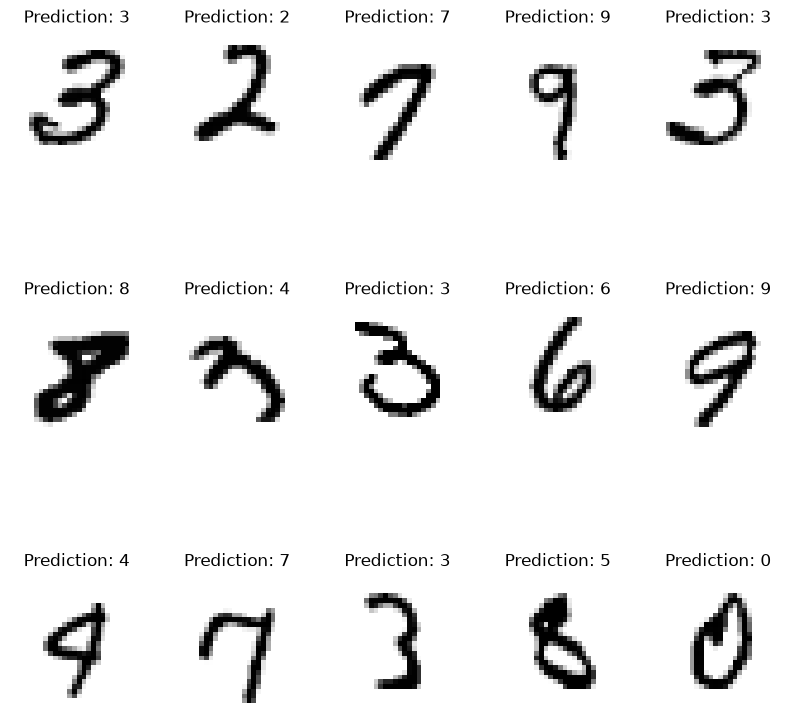

In [ ]:
fig, ax = plt.subplots(3,5, figsize=[10, 10])
for i in range(15):
    ax[i//5, i%5].imshow(np.reshape(X_test[i], (28, 28)), cmap='binary')
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(f"Prediction: {X_test_pred[i]}")